# Statistical physics: counting microstates

**What we are doing.** We have $N$ *distinguishable* particles (imagine numbered balls 1, 2, 3, ...)
and a ladder of energy levels $E_0, E_1, E_2, \dots$. A **macrostate** says only *how many* particles
sit on each level -- the occupation numbers $(n_0, n_1, n_2, \dots)$. A **microstate** says *exactly
which* numbered particle sits on which level. The central quantity of statistical physics is the
**multiplicity** $W$: how many microstates belong to one macrostate.

$$W \;=\; \frac{N!}{n_0!\,n_1!\,n_2!\cdots}, \qquad N = n_0 + n_1 + n_2 + \cdots$$

The worked example from the text is $W_{\rm MB} = \dfrac{6!}{3!\,2!\,1!} = 60$.

This notebook explains where the factorials come from, computes $W$ four different ways in Python,
turns counts into probabilities, and points out the beginner traps (off-by-one indexing, float vs
exact integers). Comments connect the math to arrays, loops, and C-style indexing. It needs only the
standard scientific-Python packages -- nothing to install.

In [1]:
# Trusted standard-library and scientific packages only -- nothing to install.
import sys
import math                          # math.factorial, math.comb  -> exact ints
from fractions import Fraction       # exact rational numbers (no rounding)
import sympy as sp                   # symbolic exact arithmetic
from itertools import permutations, product
import matplotlib.pyplot as plt
print("python", sys.version.split()[0], "| sympy", sp.__version__)

python 3.13.7 | sympy 1.14.0


## Goal 1 -- Distinguishable microstates

"Distinguishable" means the particles carry identities (labels). If particle 1 is on level 0 and
particle 2 is on level 1, that is a *different* microstate from particle 2 on level 0 and particle 1
on level 1 -- even though the macrostate "one particle on each level" is the same.

With $N$ distinguishable particles there are $N!$ ways to order them. Below we list all $3! = 6$
orderings of three labelled particles A, B, C. Each ordering is one way to hand them out to three
distinct slots.

In [2]:
particles = ["A", "B", "C"]
orderings = list(permutations(particles))     # every distinguishable arrangement
for o in orderings:
    print(o)
print("count =", len(orderings), "= 3! =", math.factorial(3))
assert len(orderings) == math.factorial(3)

('A', 'B', 'C')
('A', 'C', 'B')
('B', 'A', 'C')
('B', 'C', 'A')
('C', 'A', 'B')
('C', 'B', 'A')
count = 6 = 3! = 6


## Goal 2 -- Why the factorials appear

Start by lining up all $N$ particles in a row: that can be done in $N!$ ways. Now hand the first
$n_0$ of them to level 0, the next $n_1$ to level 1, and so on. Two orderings that differ only by
**shuffling particles already inside the same level** give the *same* microstate, because a level
does not record any internal order. There are $n_0!$ such shuffles inside level 0, $n_1!$ inside
level 1, and so on. So we have counted every microstate $n_0!\,n_1!\cdots$ times, and must divide:

$$W = \frac{N!}{n_0!\,n_1!\,n_2!\cdots}.$$

This number is called a **multinomial coefficient**. When there are only two levels it becomes the
familiar binomial coefficient $\binom{N}{n_1}$.

## Goal 3 -- Reproduce the example $6!/(3!\,2!\,1!) = 60$

Six particles, with 3 on level 0, 2 on level 1, and 1 on level 2. We compute $W$ and assert it
equals 60.

In [3]:
occ = [3, 2, 1]                     # occupation numbers n0, n1, n2  (an array, index 0..2)
N = sum(occ)                        # total particles = 6
W = math.factorial(N)
for n in occ:
    W //= math.factorial(n)         # // is INTEGER division: the result stays an exact int
print("N =", N, " occupations =", occ)
print("W = 6! / (3! 2! 1!) =", W)
assert W == 60                      # the textbook answer

N = 6  occupations = [3, 2, 1]
W = 6! / (3! 2! 1!) = 60


### The same number, four ways

Each of these is a valid tool; they differ in the **return type** (Goal 8), which we look at next.
- `math.factorial` with integer division `//` -> exact `int`
- a product of `math.comb` (choose the particles for each level in turn) -> exact `int`
- `fractions.Fraction` -> exact rational, guaranteed no rounding
- `sympy` factorials -> exact symbolic integer

In [4]:
# (1) factorial with integer division
W_fact = math.factorial(6) // (math.factorial(3) * math.factorial(2) * math.factorial(1))

# (2) product of binomial coefficients: choose 3 of 6, then 2 of the remaining 3, then 1 of 1
W_comb = math.comb(6, 3) * math.comb(3, 2) * math.comb(1, 1)

# (3) Fraction keeps it exact even if we divide instead of using //
W_frac = Fraction(math.factorial(6), math.factorial(3)*math.factorial(2)*math.factorial(1))

# (4) sympy factorials
W_sym = sp.factorial(6) / (sp.factorial(3)*sp.factorial(2)*sp.factorial(1))

print("factorial //      :", W_fact)
print("product of combs  :", W_comb, "  (20 * 3 * 1)")
print("Fraction          :", W_frac)
print("sympy             :", W_sym)
assert W_fact == W_comb == 60
assert W_frac == 60 and W_sym == 60

factorial //      : 60
product of combs  : 60   (20 * 3 * 1)
Fraction          : 60
sympy             : 60


## Goal 7 -- The count in decimal, binary, and hexadecimal

A computer stores 60 as a pattern of bits. Python shows the same integer in three common bases.
Binary groups bits; hexadecimal groups them four at a time (one hex digit = 4 bits = one "nibble").
These are the forms you meet in C when you write `0b111100` or `0x3C`.

In [5]:
n = 60
print(f"decimal      : {n}")
print(f"binary       : {bin(n)}   (also {n:08b} with 8 fixed bits)")
print(f"hexadecimal  : {hex(n)}   (also 0x{n:02X})")
# round-trip check: parsing the strings back gives the same integer
assert int("0b111100", 2) == 60 and int("0x3c", 16) == 60

decimal      : 60
binary       : 0b111100   (also 00111100 with 8 fixed bits)
hexadecimal  : 0x3c   (also 0x3C)


## Goal 8 -- Return types, and why they matter

The same value 60 can arrive as different Python types. For *counting*, exactness matters: factorials
grow huge fast, and `float` silently loses digits beyond about 15-16 significant figures. Prefer
`int` (with `//`), `Fraction`, or `sympy` for exact work; use `float` only when an approximate decimal
is acceptable.

In [6]:
examples = {
    "int (factorial //)": math.factorial(6)//(math.factorial(3)*math.factorial(2)*math.factorial(1)),
    "float (plain /)"    : math.factorial(6)/(math.factorial(3)*math.factorial(2)*math.factorial(1)),
    "Fraction"           : Fraction(720, 12),
    "sympy Rational"     : sp.Rational(720, 12),
}
for name, val in examples.items():
    print(f"{name:22s} value={val!s:8} type={type(val).__name__}")
# the float equals 60.0 here, but is a float (approximate); the others are exact
assert isinstance(examples["int (factorial //)"], int)
assert isinstance(examples["float (plain /)"], float)
assert isinstance(examples["Fraction"], Fraction)
assert examples["Fraction"] == 60 and examples["sympy Rational"] == 60

int (factorial //)     value=60       type=int
float (plain /)        value=60.0     type=float
Fraction               value=60       type=Fraction
sympy Rational         value=60       type=Integer


## Goal 4 -- Probabilities from microstate counts

The **fundamental postulate** of statistical mechanics: every microstate is equally likely. So the
probability of a macrostate is its share of all microstates,
$$P(\text{macrostate}) = \frac{W(\text{macrostate})}{\sum_{\text{all macrostates}} W}.$$
For $N=6$ distinguishable particles free to occupy 3 levels, the total number of microstates is
$3^6 = 729$ (each particle independently picks one of 3 levels). We enumerate every macrostate
$(n_0, n_1, n_2)$ with $n_0+n_1+n_2=6$, add up their multiplicities (which must give 729), and read
off probabilities as exact fractions.

In [7]:
def multiplicity(occ):
    """W = N! / prod(n_i!) for an occupation array occ = [n0, n1, ...]. Returns an exact int."""
    W = math.factorial(sum(occ))
    for n in occ:
        W //= math.factorial(n)
    return W

levels = 3
macrostates = [(a, b, 6-a-b) for a in range(7) for b in range(7-a)]   # all (n0,n1,n2), sum = 6
Ws = {m: multiplicity(m) for m in macrostates}
total = sum(Ws.values())
print("number of macrostates:", len(macrostates))
print("sum of all multiplicities:", total, "= 3^6 =", 3**6)
assert total == levels**6                                             # multinomial theorem check

# probability of the textbook macrostate (3,2,1), exact
P_321 = Fraction(Ws[(3, 2, 1)], total)
print("P(3,2,1) =", Ws[(3,2,1)], "/", total, "=", P_321, "=", float(P_321))

# the MOST probable macrostate is the most even one, (2,2,2)
best = max(Ws, key=Ws.get)
print("most probable macrostate:", best, "with W =", Ws[best])
assert best == (2, 2, 2) and Ws[best] == 90
# probabilities over all macrostates sum to exactly 1
assert sum(Fraction(w, total) for w in Ws.values()) == 1

number of macrostates: 28
sum of all multiplicities: 729 = 3^6 = 729
P(3,2,1) = 60 / 729 = 20/243 = 0.0823045267489712
most probable macrostate: (2, 2, 2) with W = 90


## Goal 5 -- Off-by-one errors when indexing $E_0, E_1, E_2, \dots$

Energy levels are numbered from **zero**, exactly like Python lists and C arrays. If there are
`L` levels, the valid indices are `0, 1, ..., L-1` -- **not** `1, ..., L`. The occupation array lines
up with the levels: `occ[0]` is the number on `E0`.

Common mistakes and the fix:
- looping `for i in range(1, L)` skips level 0 -> use `range(L)` (or `range(0, L)`);
- writing `occ[L]` is out of bounds -> the last valid index is `L-1`;
- in C, `for (int i = 0; i <= L; i++)` runs one step too far -> use `i < L`.

`enumerate` pairs each index with its value and removes the guesswork.

In [8]:
occ = [3, 2, 1]
L = len(occ)                        # number of levels = 3, so indices are 0,1,2
print("valid indices:", list(range(L)), " last index:", L-1)
for i, n in enumerate(occ):         # i = 0,1,2 in lockstep with the level number
    print(f"level E{i}: {n} particle(s)")
# C-style loop, written safely in Python:  for (int i = 0; i < L; i++)
total = 0
for i in range(L):                  # range(L) stops BEFORE L -> no off-by-one
    total += occ[i]
assert total == 6
# a wrong loop would raise IndexError -- we confirm the guard works:
try:
    _ = occ[L]                      # occ[3] does not exist
    raise AssertionError("should have been out of range")
except IndexError:
    print("occ[L] correctly raises IndexError (L is one past the last index)")

valid indices: [0, 1, 2]  last index: 2
level E0: 3 particle(s)
level E1: 2 particle(s)
level E2: 1 particle(s)
occ[L] correctly raises IndexError (L is one past the last index)


## Goal 10 -- Connect the math to arrays and loops

The formula is just a loop over an occupation **array**. Here is `multiplicity` again with
beginner comments, mirroring how you would write it in C: read `N` from the array, then divide by
each `n_i!` in a `for` loop over the indices.

In [9]:
def multiplicity_verbose(occ):
    # occ is an array (Python list) of occupation numbers, one per energy level.
    N = 0
    for i in range(len(occ)):       # C: for (int i = 0; i < len; i++)
        N += occ[i]                 # accumulate the total particle count
    W = math.factorial(N)           # numerator N!
    for i in range(len(occ)):       # divide by n_i! for each level i
        W //= math.factorial(occ[i])
    return W                         # exact int

# tests on several occupation arrays
assert multiplicity_verbose([3, 2, 1]) == 60
assert multiplicity_verbose([2, 2, 2]) == 90
assert multiplicity_verbose([6]) == 1            # all in one level: only one microstate
assert multiplicity_verbose([1, 1, 1, 1, 1, 1]) == math.factorial(6)  # all separate: 6! = 720
print("multiplicity_verbose passes all checks")

multiplicity_verbose passes all checks


## The physics payoff: the most probable macrostate dominates

Two levels make the counts a binomial, $W(n_1)=\binom{N}{n_1}$. As $N$ grows the distribution of
microstates over macrostates becomes sharply peaked at the most even split -- that peak *is* the
equilibrium (Maxwell-Boltzmann) distribution, and fluctuations away from it become vanishingly
unlikely. This is why a large system has a definite thermodynamic state.

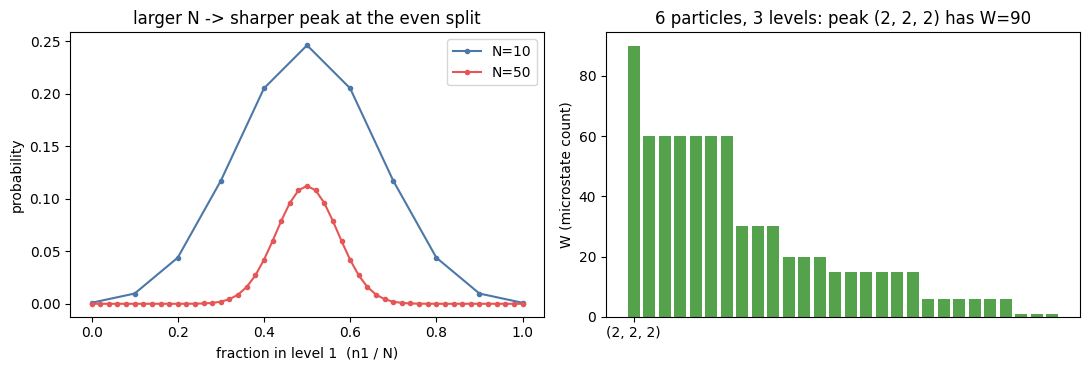

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for N, c in [(10, "#4C78A8"), (50, "#E45756")]:
    n1 = list(range(N+1))
    W = [math.comb(N, k) for k in n1]
    P = [w / 2**N for w in W]                    # probability of each macrostate
    ax[0].plot([k/N for k in n1], P, "o-", ms=3, color=c, label=f"N={N}")
ax[0].set_xlabel("fraction in level 1  (n1 / N)"); ax[0].set_ylabel("probability")
ax[0].set_title("larger N -> sharper peak at the even split"); ax[0].legend()

# the 3-level example: multiplicity of every macrostate, peak at (2,2,2)
labels = [f"{m}" for m in macrostates]
vals = [Ws[m] for m in macrostates]
order = sorted(range(len(vals)), key=lambda i: -vals[i])
ax[1].bar(range(len(vals)), [vals[i] for i in order], color="#54A24B")
ax[1].set_xticks([0]); ax[1].set_xticklabels([labels[order[0]]])
ax[1].set_ylabel("W (microstate count)")
ax[1].set_title(f"6 particles, 3 levels: peak {macrostates[order[0]]} has W={vals[order[0]]}")
plt.tight_layout(); plt.show()

## Goal 9 -- A block of tests to catch mistakes

Running these assertions is a fast self-check: if any line fails, something upstream is wrong.

In [11]:
# multiplicity basics
assert multiplicity([3, 2, 1]) == 60
assert multiplicity([0, 6, 0]) == 1                      # zeros are fine: 0! = 1
assert multiplicity([2, 2, 2]) > multiplicity([3, 2, 1]) # the even split is more probable
# multinomial theorem: multiplicities over all macrostates sum to (levels)^N
assert sum(multiplicity(m) for m in macrostates) == 3**6
# probabilities are a valid distribution: each in [0,1], summing to 1 exactly (Fractions)
probs = [Fraction(multiplicity(m), 3**6) for m in macrostates]
assert all(0 <= p <= 1 for p in probs) and sum(probs) == 1
# exact vs float: Fraction is exact, float only approximate
assert Fraction(math.factorial(20), math.factorial(20)) == 1
assert math.factorial(3) == 6 and math.comb(6, 3) == 20
print("all tests passed")

all tests passed


## Summary

- A **macrostate** is the occupation array $(n_0, n_1, \dots)$; a **microstate** is a specific
  labelling of distinguishable particles onto levels.
- The multiplicity $W = N!/(n_0!\,n_1!\cdots)$ counts microstates; the factorials come from
  ordering all particles ($N!$) and then dividing out the orders that do not matter inside each
  level ($n_i!$).
- The example $6!/(3!\,2!\,1!) = 60$ was reproduced four ways (int, `math.comb`, `Fraction`,
  `sympy`), with attention to return types and exactness.
- Probabilities are counts divided by the total, best kept exact with `Fraction`.
- Energy levels index from **0**; loop with `range(L)` and `enumerate` to avoid off-by-one errors,
  exactly as with C arrays.
- The most probable macrostate dominates as $N$ grows -- the statistical origin of equilibrium, and
  the first step toward entropy $S = k_B \ln W$.